# The no error weighted model: six uncertainty-interval methods, six fields

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks_2" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d.glimmer import checkpoint as ckpt
from azt1d.glimmer import uncertainty as unc

plotting.apply_style()

CKPT_DIR = PROJECT_ROOT / "data" / "processed" / "checkpoints" / "cnn_lstm_v0"
METHOD_LABELS = {
    "Conformal": "Conformal (statistics, model-agnostic)",
    "GARCH": "GARCH (finance)",
    "Analog Ensemble": "Analog Ensemble (weather)",
    "EWMA": "EWMA volatility (finance, RiskMetrics)",
    "Normalized Conformal": "Locally weighted conformal (statistics)",
    "Time-of-day Quantiles": "Time-of-day quantiles (climatology)",
}

df = loading.load_real_dataset(PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data" / "processed")
subject_ids = sorted(int(s) for s in df["subject_id"].unique())

engines, actuals, max_gap = {}, {}, 0.0
for sid in subject_ids:
    res = ckpt.load_result(CKPT_DIR, sid)
    df_subject = df[df["subject_id"] == sid].reset_index(drop=True)
    val, test = unc.forecast_frames(res, df_subject)
    max_gap = max(max_gap, unc.matches_stored_predictions(test, res))
    engines[sid] = unc.BandEngine(val, test)
    actuals[sid] = test.actual

assert max_gap < 0.05, "rebuilt predictions do not match the checkpoints"
actual_all = np.concatenate([actuals[s] for s in subject_ids])
print(f"Rebuilt forecasts and bands for {len(subject_ids)} patients, {len(actual_all):,} test predictions.")

Rebuilt forecasts and bands for 25 patients, 60,009 test predictions.


## The danger-caught vs. false-trigger curve, one line per method

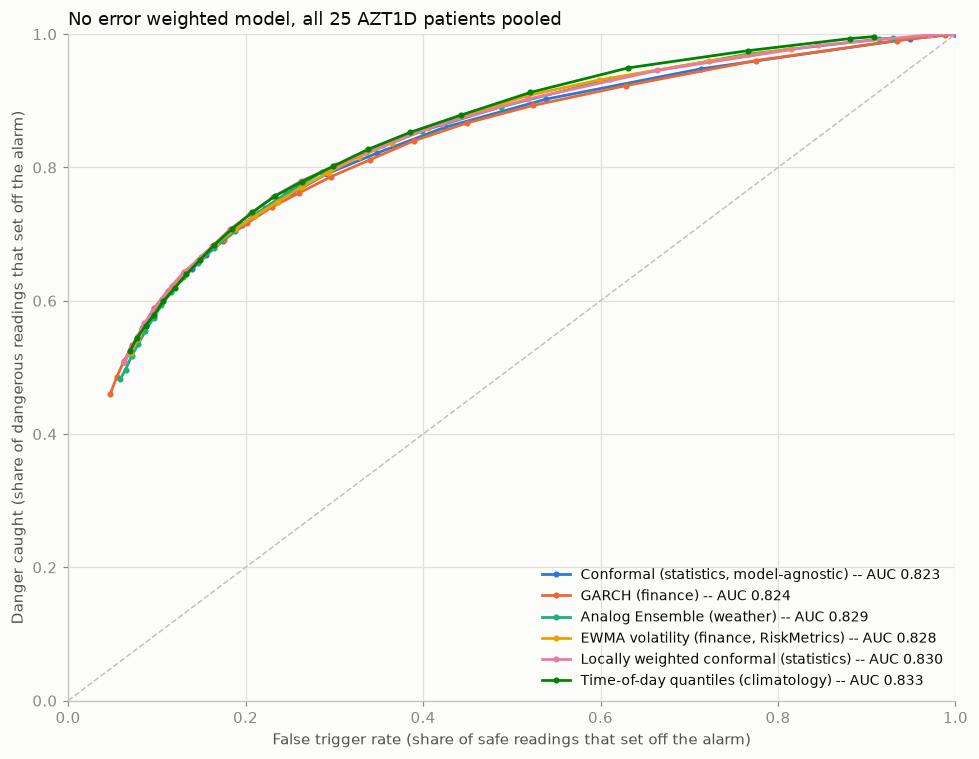

In [2]:
def pooled_bands(method, level):
    los, his = zip(*(engines[s].bands(method, level) for s in subject_ids))
    return np.concatenate(los), np.concatenate(his)


fig, ax = plt.subplots(figsize=(9, 7))
for method, color in zip(unc.ALL_METHODS, plotting.CATEGORICAL):
    curve = [unc.trigger_metrics(actual_all, *pooled_bands(method, lv)) for lv in unc.DEFAULT_AUC_LEVELS]
    x = [c["false_trigger_rate"] for c in curve]
    y = [c["danger_caught"] for c in curve]
    auc = np.trapezoid([0.0] + y + [1.0], [0.0] + x + [1.0])
    ax.plot(x, y, color=color, linewidth=1.8, marker="o", markersize=3, label=f"{METHOD_LABELS[method]} -- AUC {auc:.3f}")
ax.plot([0, 1], [0, 1], color=plotting.BASELINE, linewidth=1, linestyle="--")
ax.set_xlabel("False trigger rate (share of safe readings that set off the alarm)")
ax.set_ylabel("Danger caught (share of dangerous readings that set off the alarm)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title("No error weighted model, all 25 AZT1D patients pooled", loc="left")
fig.tight_layout()
plt.show()